In [53]:
import pandas as pd
import numpy as np

df = pd.read_excel("D:\ML assignments and practice\maharastra-AC-2019.xlsx")
df.shape


(288, 21)

In [54]:
df = df.drop(columns=[
    'Unnamed: 0',
    'State',
    'Polling Date',
    'Counting Date',
    'Result Date',
    'AC Name'
])

In [55]:
df['Turnout_pct'] = df['Turnout'].str.extract(r'([\d\.]+)').astype(float)

In [56]:
for col in ['Male', 'Female', 'other', 'Total Electors']:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r'([\d,]+)')[0]
        .str.replace(',', '', regex=False)
        .astype(float)
    )


In [57]:
df = df.drop(columns=['Turnout'])

In [58]:
df[['Party', 'Turnout_pct', 'Total Electors', 'Male', 'Female']].isna().sum()

Party             0
Turnout_pct       0
Total Electors    0
Male              0
Female            0
dtype: int64

In [59]:
required_cols = [
    'Party',
    'Turnout_pct',
    'Total Electors',
    'Male',
    'Female',
    'Region',
    'District'
]

df = df[df[required_cols].notna().all(axis=1)]
df.shape


(288, 15)

In [60]:
y = df['Party']
X = df.drop(columns=['Party'])

y.value_counts()
X.shape


(288, 14)

In [61]:
df.shape


(288, 15)

In [62]:
y.value_counts()


Party
Bharatiya Janta Party                     105
Shiv Sena                                  56
Nationalist Congress Party                 54
Indian National Congress                   44
Independent                                13
Bahujan Vikas Aaghadi                       3
Prahar Janshakti Party                      2
All India Majlis-E-Ittehadul Muslimeen      2
Samajwadi Party                             2
Swabhimani Paksha                           1
Rashtriya Samaj Paksha                      1
Peasants And Workers Party Of India         1
Communist Party Of India (Marxist)          1
Maharashtra Navnirman Sena                  1
Krantikari Shetkari Party                   1
Jan Surajya Shakti                          1
Name: count, dtype: int64

In [64]:
group_1 = [
    'Bharatiya Janta Party',
    'Shiv Sena',
    'Prahar Janshakti Party',
    'Swabhimani Paksha',
    'Rashtriya Samaj Paksha',
    'Jan Surajya Shakti',
    'Krantikari Shetkari Party'
]

group_2 = [
    'Nationalist Congress Party',
    'Indian National Congress',
    'Bahujan Vikas Aaghadi',
    'All India Majlis-E-Ittehadul Muslimeen',
    'Samajwadi Party',
    'Peasants And Workers Party Of India',
    'Communist Party Of India (Marxist)'
]


In [65]:
def assign_bloc(party):
    if party in group_1:
        return 'BJP/NDA Bloc'
    elif party in group_2:
        return 'Congress–NCP Bloc'
    else:
        return np.nan

df['Bloc'] = df['Party'].apply(assign_bloc)


In [66]:
df_bloc = df.dropna(subset=['Bloc'])
df_bloc.shape


(272, 16)

In [70]:
X_bloc = df_bloc.drop(columns=['Party', 'Bloc'])
y_bloc = df_bloc['Bloc']


In [71]:
X_bloc.select_dtypes(include='object').columns


Index(['AC', 'Type', 'MLA', 'Candidates', 'Age', 'Age-young', 'Region',
       'District'],
      dtype='object')

In [72]:
X_bloc_encoded = pd.get_dummies(X_bloc, drop_first=True)


In [73]:
X_bloc_encoded.select_dtypes(include='object').columns


Index([], dtype='object')

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bloc_encoded,
    y_bloc,
    test_size=0.2,
    random_state=42,
    stratify=y_bloc
)


In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))


                   precision    recall  f1-score   support

     BJP/NDA Bloc       0.66      0.76      0.70        33
Congress–NCP Bloc       0.53      0.41      0.46        22

         accuracy                           0.62        55
        macro avg       0.59      0.58      0.58        55
     weighted avg       0.61      0.62      0.61        55



In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))


                   precision    recall  f1-score   support

     BJP/NDA Bloc       0.63      0.79      0.70        33
Congress–NCP Bloc       0.50      0.32      0.39        22

         accuracy                           0.60        55
        macro avg       0.57      0.55      0.55        55
     weighted avg       0.58      0.60      0.58        55



In [77]:
X_bloc_encoded.shape

(272, 1402)

In [78]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_bloc_encoded.columns
).sort_values(ascending=False)

importances.head(10)


Total Electors                    0.045335
Male                              0.042900
AC_No                             0.041020
Female                            0.039859
Region_West Maharashtra - Pune    0.014640
Turnout_pct                       0.010792
District_Aurangabad               0.007840
Type_SC                           0.006957
District_Yavatmal                 0.006501
District_Mumbai (Suburban)        0.005909
dtype: float64

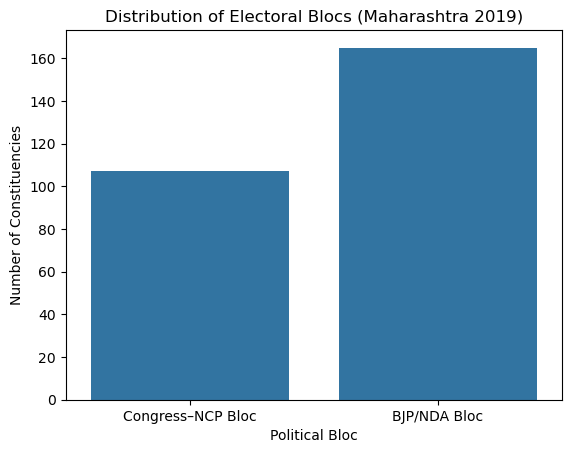

In [84]:
#The dataset shows a competitive distribution between the two major political blocs, making the classification task non-trivial

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_bloc, x='Bloc')
plt.title('Distribution of Electoral Blocs (Maharashtra 2019)')
plt.xlabel('Political Bloc')
plt.ylabel('Number of Constituencies')
plt.show()


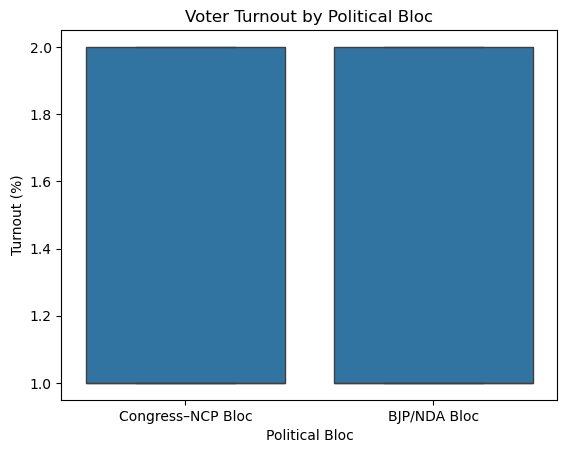

In [85]:
#Differences in turnout distribution suggest varying mobilization efficiency across blocs

sns.boxplot(data=df_bloc, x='Bloc', y='Turnout_pct')
plt.title('Voter Turnout by Political Bloc')
plt.xlabel('Political Bloc')
plt.ylabel('Turnout (%)')
plt.show()


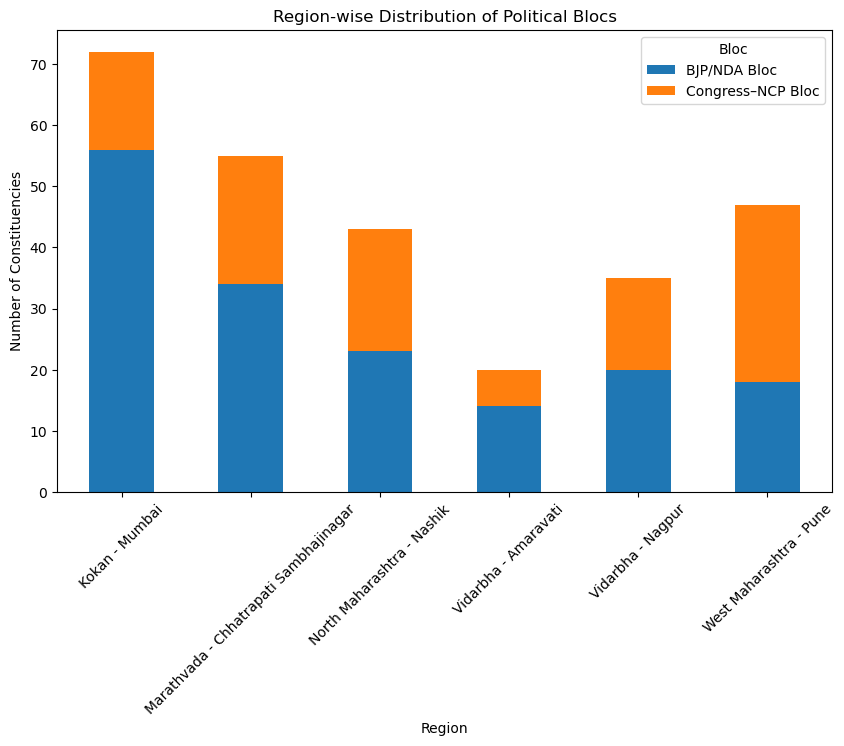

In [86]:
#Region-wise bloc dominance

region_bloc = (
    df_bloc
    .groupby(['Region', 'Bloc'])
    .size()
    .unstack(fill_value=0)
)

region_bloc.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Region-wise Distribution of Political Blocs')
plt.xlabel('Region')
plt.ylabel('Number of Constituencies')
plt.xticks(rotation=45)
plt.show()


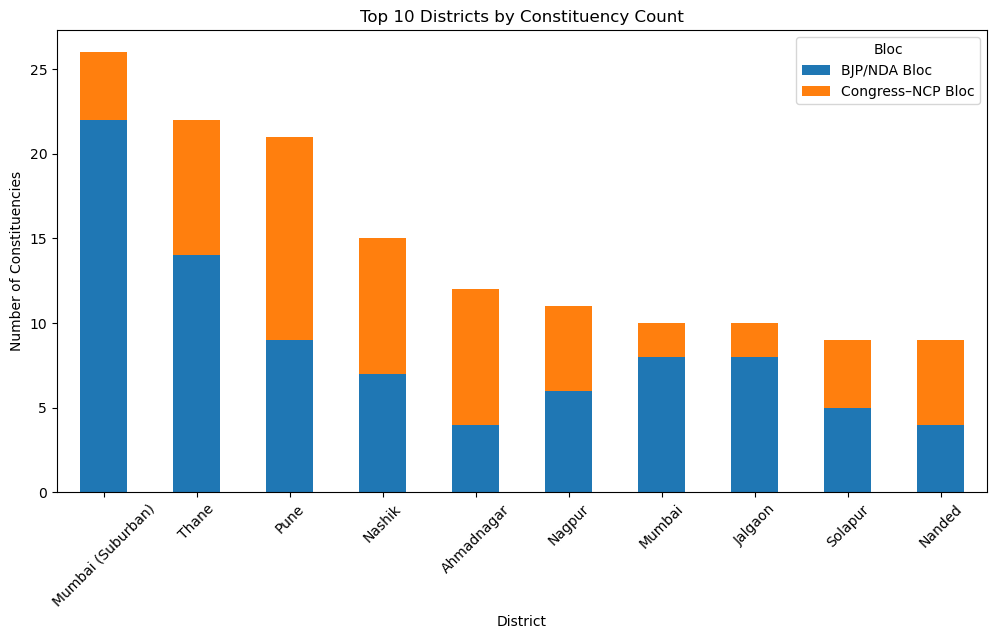

In [87]:
#District-level competitiveness

district_bloc = (
    df_bloc
    .groupby(['District', 'Bloc'])
    .size()
    .unstack(fill_value=0)
)

district_bloc['Total'] = district_bloc.sum(axis=1)
district_bloc = district_bloc.sort_values('Total', ascending=False).head(10)

district_bloc.drop(columns='Total').plot(
    kind='bar', stacked=True, figsize=(12,6)
)

plt.title('Top 10 Districts by Constituency Count')
plt.xlabel('District')
plt.ylabel('Number of Constituencies')
plt.xticks(rotation=45)
plt.show()


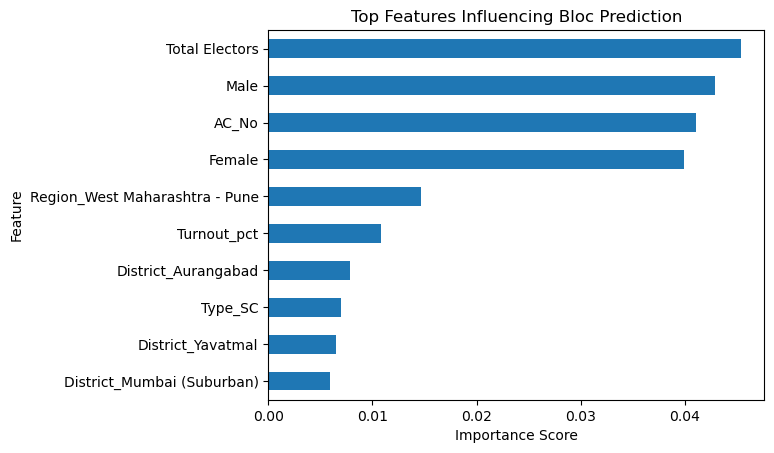

In [88]:
#Feature importance visualization

top_features = importances.head(10)

top_features.plot(kind='barh')
plt.title('Top Features Influencing Bloc Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()
